<a href="https://colab.research.google.com/github/shrutijadhav25-cell/Data_science_lab_SE_A_69/blob/main/PRACTICAL8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [3]:
import zipfile

with zipfile.ZipFile("/content/ml-latest-small.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [4]:
import os
os.listdir("data/ml-latest-small")

['README.txt', 'ratings.csv', 'movies.csv', 'links.csv', 'tags.csv']

In [5]:
ratings = pd.read_csv("data/ml-latest-small/ratings.csv")
movies = pd.read_csv("data/ml-latest-small/movies.csv")

data = pd.merge(ratings, movies, on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [8]:
print(data.columns)

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')


In [9]:
print(data.shape)

(100836, 6)


In [10]:
print(data.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


Ratings Data:

0     4.0
1     4.0
2     4.0
3     5.0
4     5.0
5     3.0
6     5.0
7     4.0
8     5.0
9     5.0
10    5.0
11    5.0
12    3.0
13    5.0
14    4.0
15    5.0
16    3.0
17    3.0
18    5.0
19    4.0
Name: rating, dtype: float64

Rating Frequency:

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


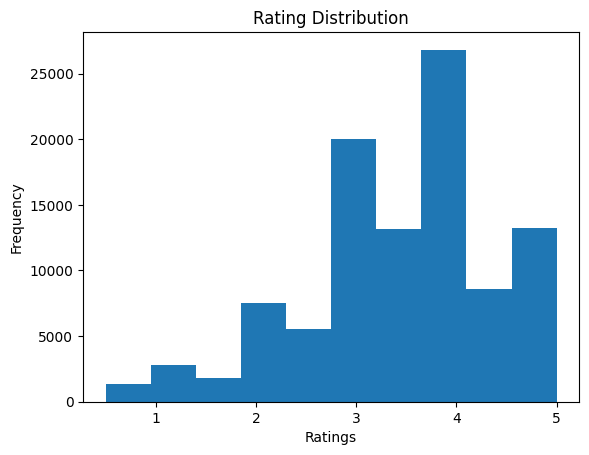

In [11]:
import matplotlib.pyplot as plt
print("Ratings Data:\n")
print(data['rating'].head(20))
print("\nRating Frequency:\n")
print(data['rating'].value_counts().sort_index())
plt.figure()
plt.hist(data['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")

plt.show()

In [13]:
data['genres'] = data['genres'].astype('category').cat.codes

X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

In [15]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.9645483151460537


In [17]:
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

In [18]:
y_cls = data['rating_class']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

In [23]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_cls))
print(classification_report(y_test, y_pred_cls))

Accuracy: 0.6599067830226101
              precision    recall  f1-score   support

           0       0.57      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.66     20168



Confusion Matrix:
 [[4005 3824]
 [3035 9304]]

TN: 4005
FP: 3824
FN: 3035
TP: 9304


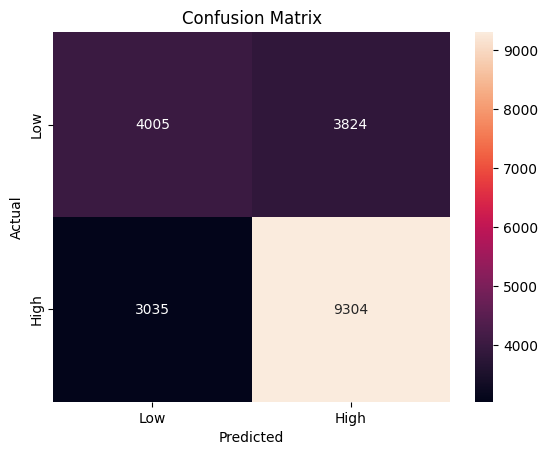

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_cls)
print("Confusion Matrix:\n", cm)
tn, fp, fn, tp = cm.ravel()
print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Low", "High"],
            yticklabels=["Low", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()